In [226]:
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.ndimage import uniform_filter, gaussian_filter
# from skimage.measure import block_reduce
import cv2
from PIL import Image
from mpl_toolkits.axes_grid1 import make_axes_locatable
from skimage.metrics import structural_similarity

In [227]:
from cv2 import LUT


LUT_2 = {
    255: 0.663,
    0: 0.9229,
}

LUT_3 = {
    255: 0.663,
    127: 0.7929,
    0: 0.9229,
}

LUT_4 = {
    255: 0.663,
    170: 0.7495,
    84: 0.8362,
    0: 0.9229,
}

LUT_5 = {
    255: 0.663,
    191: 0.7282,
    127: 0.7929,
    63: 0.858,
    0: 0.9229, }

# swatch_means = [0.182, 0.215, 0.231, 0.205, 0.135]
# mean_of_swatch_means = np.mean(swatch_means)

swatch_means = {
    255: 0.182,
    191: 0.215,
    127: 0.231,
    63: 0.205,
    0: 0.135,
}
swatch_means[170] = (swatch_means[191] + swatch_means[127]) / 2
swatch_means[84] = (swatch_means[127] + swatch_means[63]) / 2

mean_of_swatch_means = np.mean(list(swatch_means.values()))

LUTS = {
    2: LUT_2,
    3: LUT_3,
    4: LUT_4,
    5: LUT_5,
}

for k, v in LUT_5.items():
    print(k, v, swatch_means[k], LUT_5[k] - swatch_means[k], )


def lut_mapping(input, qlvl):
    LUT = LUTS.get(qlvl)
    if LUT is None:
        raise ValueError(f"Unsupported quantization level: {qlvl}")

    # Find the closest key in the LUT to the input value
    # We do this in case some values are slightly off due to rounding
    # We throw an error if the input is too far from the LUT keys
    diff = {k: abs(int(k) - int(input)) for k in LUT.keys()}
    if all(diff.values()) > 5:
        raise ValueError(
            f"Input value {input} is too far from LUT keys: {LUT.keys()}")
    closest_key = min(LUT.keys(), key=diff.get)
    return LUT[closest_key] - swatch_means[closest_key]

255 0.663 0.182 0.48100000000000004
191 0.7282 0.215 0.5132
127 0.7929 0.231 0.5619000000000001
63 0.858 0.205 0.653
0 0.9229 0.135 0.7879


In [ ]:
from matplotlib.colorbar import make_axes


def set_plot_style():
    from matplotlib import font_manager

    # Path to the Libertine font file
    font_path = '/usr/share/fonts/opentype/linux-libertine/LinLibertine_R.otf'

    # Add the font to Matplotlib's font manager
    font_manager.fontManager.addfont(font_path)
    biolinum_font = font_manager.FontProperties(fname=font_path)

    # Set Libertine as the default font
    plt.rcParams['font.family'] = biolinum_font.get_name()

    # Customize font sizes
    plt.rcParams['axes.labelsize'] = 8  # Axis labels
    plt.rcParams['axes.titlesize'] = 10  # Plot title
    plt.rcParams['figure.titlesize'] = 12  # Figure title
    plt.rcParams['legend.fontsize'] = 6  # Legend
    plt.rcParams['legend.title_fontsize'] = 8  # Legend title
    plt.rcParams['xtick.labelsize'] = 8  # X-axis tick labels
    plt.rcParams['ytick.labelsize'] = 8  # Y-axis tick labels

    plt.rcParams['svg.fonttype'] = 'none'

    plot_color_palette = ['#d1eeea', '#A8DBD9', '#85C4C9',
                          '#68ABB8', '#4F90A6', '#3B738F', '#2a5674']
    return plot_color_palette


def rgb_to_grayscale(image_input: str | Image.Image):
    """
    Convert RGB image to grayscale and return the pixel values.

    Args:
        image_input (Union[str, Image.Image]): Path to image file or PIL Image object

    Returns:
        numpy.ndarray: Grayscale pixel values (0-255)
    """
    # Handle both file paths and PIL Image objects
    if isinstance(image_input, str):
        # Load image from file path
        img = Image.open(image_input).convert('RGB')
    else:
        # Use provided PIL Image object
        img = image_input.convert('RGB')

    # Convert to numpy array
    img_array = np.array(img)

    # Convert to grayscale using OpenCV (more accurate than PIL's convert)
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    return gray


def compare_dark_pct(img1: str, img2: str, qlvl: int, litho_size_mm: float = 200., homogenizing_size_mm: float = 10.):
    gray = np.array(rgb_to_grayscale(img1), dtype=np.uint8)
    input_img = np.array(rgb_to_grayscale(img2), dtype=np.uint8)
    if ('raw' not in img2.lower() or 'scf' in img2.lower()) and 'swatch' not in img2.lower():
        input_img = Image.fromarray(input_img)
        input_img = input_img.quantize(qlvl, method=Image.Quantize.MEDIANCUT)
        input_img = 255 - np.array(input_img, dtype=np.uint8)

    # Make sure the input image size matches the lithophane image size
    if gray.shape != input_img.shape:
        input_img = cv2.resize(
            input_img, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_LINEAR)


    blurred_gray = gaussian_filter(gray, sigma=11, mode='reflect')
    blurred_input_img = gaussian_filter(input_img, sigma=11, mode='reflect')

    ssim = structural_similarity(blurred_gray, blurred_input_img, data_range=255)
    print(f"SSIM between lithophane and input image: {ssim:.4f}")

    # Scale the input image to 0-255 range which is what we do in the lithophane tool
    img_max, img_min = np.max(input_img), np.min(input_img)
    if img_max != img_min:
        scaled_input_img = (input_img - img_min) / (img_max - img_min) * 255
    else:
        scaled_input_img = input_img.copy()

    # Calculate the filter sizes in pixels based on the lithophane size and homogenizing size
    # Assuming the lithophane image is square, we can use its height or width
    # to determine the pixel size
    litho_img_size_px = gray.shape[1]
    litho_filter_size_px = int(
        litho_img_size_px * homogenizing_size_mm / litho_size_mm)

    # Calculate the input filter size in pixels based on the input image size
    # and the same homogenizing size
    # Assuming the input image is square, we can use its height or width
    # to determine the pixel size
    input_img_size_px = scaled_input_img.shape[1]
    input_filter_size_px = int(
        input_img_size_px * homogenizing_size_mm / litho_size_mm)

    # Create masks for dark and light pixels
    dark_mask = (gray <= 80).astype(np.float32)
    light_mask = (gray >= 160).astype(np.float32)

    uniform_filter_mode = 'reflect'  # 'nearest', 'wrap', 'reflect', 'mirror'

    # calculate the ratio of dark to total pixels
    eps = 1e-6
    ratio_raw = dark_mask / (dark_mask + light_mask + eps)
    # Perform rolling average on the masks to get the homogenized dark percentage
    # ratio_map = uniform_filter(ratio_raw,
    #                            size=litho_filter_size_px,
    #                            mode=uniform_filter_mode)
    ratio_map = gaussian_filter(ratio_raw,
                                sigma=litho_filter_size_px // 2,
                                mode=uniform_filter_mode)

    # ==== BEGIN PLOTTING =====
    fig = plt.figure(figsize=(7, 4.6), constrained_layout=True)
    gs = GridSpec(2, 3,
                  width_ratios=[0.925, 1, 1],
                  height_ratios=[1, 1],)

    # ===== INPUT IMAGE =====
    input_ax = fig.add_subplot(gs[0, 0])
    input_ax.imshow(scaled_input_img, cmap='gray', vmin=0, vmax=255)
    input_ax.set_title("Input Image")
    input_ax.axis('off')
    input_ax.set_box_aspect(1)
    # ===== END INPUT IMAGE =====

    # ===== FILTERED INPUT DARK PERCENTAGE =====
    vectorized_map = np.vectorize(lambda x: lut_mapping(x, qlvl))
    mapped_img = vectorized_map(scaled_input_img)
    filtered_mapped_img = gaussian_filter(mapped_img,
                                          sigma=input_filter_size_px // 2,
                                          mode=uniform_filter_mode)
    input_mapped_ax = fig.add_subplot(gs[0, 1])
    im = input_mapped_ax.imshow(filtered_mapped_img,
                                cmap='viridis',
                                vmin=0, vmax=1)
    input_mapped_ax.set_title("Smoothed Expected DPP")
    input_mapped_ax.axis('off')
    divider = make_axes_locatable(input_mapped_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)
    input_mapped_ax.set_box_aspect(1)
    # ===== END INPUT DARK PERCENTAGE =====

    # ===== DARK PERCENTAGE DIFFERENCE =====
    diff = filtered_mapped_img - ratio_map
    diff_ax = fig.add_subplot(gs[0, 2])
    # dm = diff_ax.imshow(diff, cmap='coolwarm')
    dm = diff_ax.imshow(diff, cmap='plasma')
    diff_ax.set_title("DPP Difference")
    diff_ax.axis('off')
    divider = make_axes_locatable(diff_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(dm, cax=cax)
    diff_ax.set_box_aspect(1)
    # ===== END DARK PERCENTAGE DIFFERENCE =====

    # ===== LITHOPHANE IMAGE =====
    litho_ax = fig.add_subplot(gs[1, 0])
    litho_ax.imshow(gray, cmap='gray', vmin=0, vmax=255)
    litho_ax.set_title("Lithophane Image")
    litho_ax.axis('off')
    litho_ax.set_box_aspect(1)
    # ===== END LITHOPHANE IMAGE =====

    # ===== LITHOPHANE DARK PERCENTAGE =====
    litho_frac_ax = fig.add_subplot(gs[1, 1], anchor='W')
    lm = litho_frac_ax.imshow(ratio_map, cmap='viridis', vmin=0., vmax=1.)
    litho_frac_ax.set_title(f"Smoothed Lithophane DPP")
    litho_frac_ax.axis('off')
    divider = make_axes_locatable(litho_frac_ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(lm, cax=cax)
    litho_frac_ax.set_box_aspect(1)
    # ===== END LITHOPHANE DARK PERCENTAGE =====

    # ===== DARK PERCENTAGE DIFFERENCE HISTOGRAM =====
    hist_ax = fig.add_subplot(gs[1, 2])
    hist_ax.hist(diff.ravel(), bins=51, density=False)
    mean_diff = np.mean(diff)
    hist_ax.axvline(mean_diff, color='red', linestyle='--', linewidth=1.5)
    hist_ax.text(mean_diff + 0.01, 0.85*hist_ax.get_ylim()[1],
                 f'Mean: {mean_diff:.3f}', color='red', fontsize=8)
    hist_ax.set_title("DPP Difference\nFrequency Histogram")
    hist_ax.set_xlabel("Difference")
    hist_ax.set_ylabel("Frequency")
    hist_ax.set_box_aspect(1)
    # hist_ax.margins(x=0)
    hist_ax.yaxis.tick_right()
    hist_ax.yaxis.set_label_position("right")
    shift = 0.015
    pos = hist_ax.get_position()
    hist_ax.set_position([pos.x0,
                          pos.y0,
                          pos.width - shift,
                          pos.height])
    # ===== END DARK PERCENTAGE DIFFERENCE HISTOGRAM =====

    # plt.tight_layout()

    return fig


set_plot_style()

['#d1eeea', '#A8DBD9', '#85C4C9', '#68ABB8', '#4F90A6', '#3B738F', '#2a5674']

SSIM between lithophane and input image: 0.0025


/home/drevier/miniconda3/envs/vtp_lithophane/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


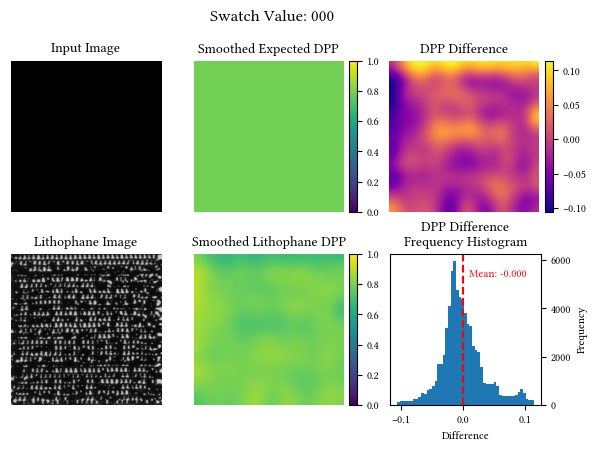

/tmp/ipykernel_30708/1279475481.py:66: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(f"./output_figs/swatch_{value:03}_dark_pct_comparison.svg")


SSIM between lithophane and input image: 0.0443


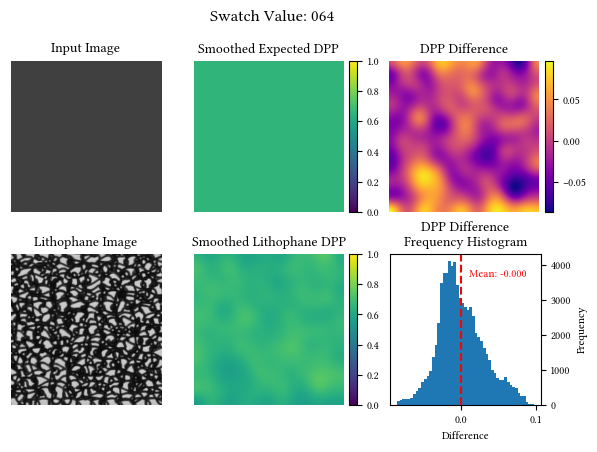

SSIM between lithophane and input image: 0.0333


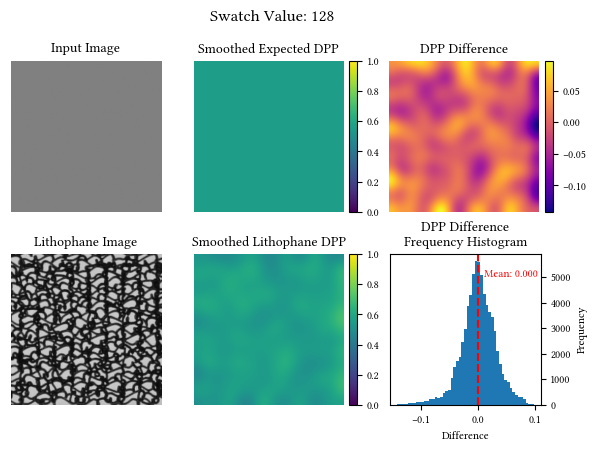

SSIM between lithophane and input image: 0.0399


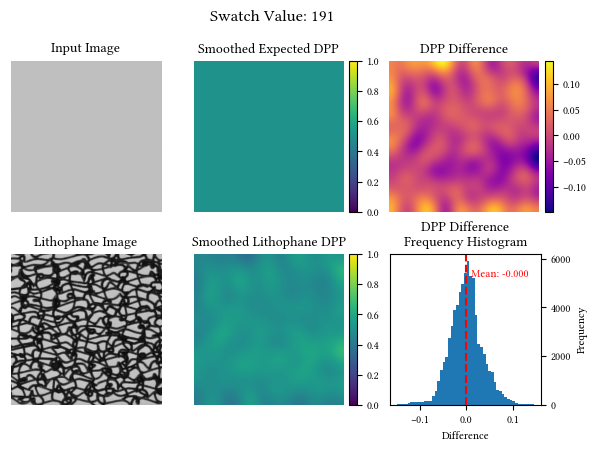

SSIM between lithophane and input image: 0.0458


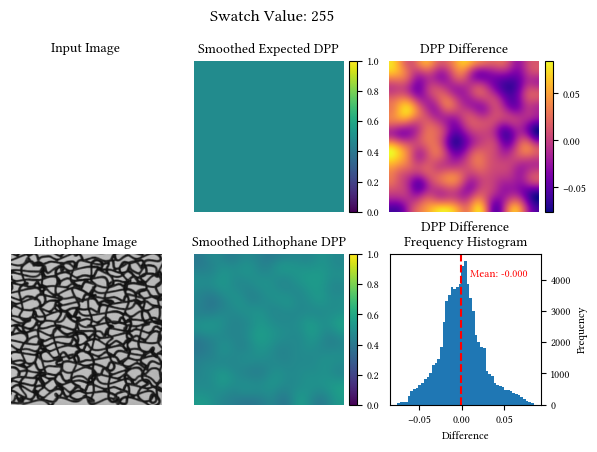

SSIM between lithophane and input image: 0.0342


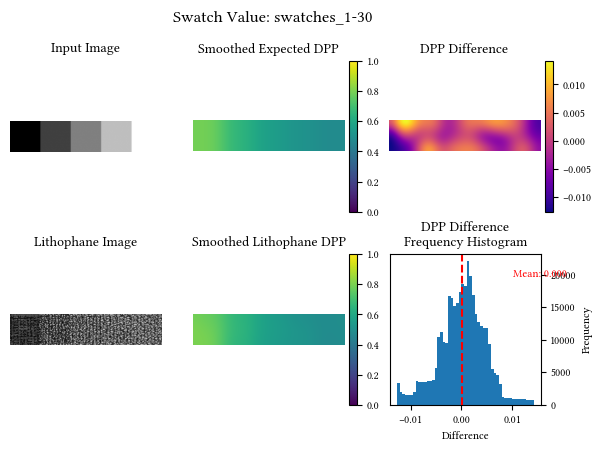

In [229]:
# Calibration Swatch Analysis
# Partition the litho image into swatches and save them as images
# litho_img = rgb_to_grayscale('./images/swatches_Q5_1-30.JPG')
# width = litho_img.shape[1]

# swatches = {}
# values = [0, 64, 128, 191, 255]
# for i, value in enumerate(values):
#     swatches[value] = litho_img[:, i *
#                                 (width // len(values)):(i + 1) * (width // len(values))]

# for value, swatch in swatches.items():
#     plt.figure(figsize=(2, 2))
#     plt.imshow(swatch, cmap='gray', vmin=0, vmax=255)
#     plt.title(f"Swatch Value: {value}")
#     plt.axis('off')
#     plt.show()

#     img = Image.fromarray(swatch)
#     img.save(f'./images/swatch_{value:03}.png')


swatch_pairs = {
    0: {
        'litho_img': './images/swatches/swatch_000.png',
        'input_img': '../images/swatches/swatch_000_input.png',
        'qlvl': 5,
    },
    64: {
        'litho_img': './images/swatches/swatch_064.png',
        'input_img': '../images/swatches/swatch_064_input.png',
        'qlvl': 5,
    },
    128: {
        'litho_img': './images/swatches/swatch_128.png',
        'input_img': '../images/swatches/swatch_128_input.png',
        'qlvl': 5,
    },
    191: {
        'litho_img': './images/swatches/swatch_191.png',
        'input_img': '../images/swatches/swatch_191_input.png',
        'qlvl': 5,
    },
    255: {
        'litho_img': './images/swatches/swatch_255.png',
        'input_img': '../images/swatches/swatch_255_input.png',
        'qlvl': 5,
    },
    'swatches_1-30': {
        'litho_img': "./images/swatches_Q5_1-30.JPG",
        'input_img': "../images/swatches.png",
        'qlvl': 5
    },
}

for value, pair in swatch_pairs.items():
    litho_img = pair['litho_img']
    input_img = pair['input_img']
    qlvl = pair['qlvl']

    fig = compare_dark_pct(litho_img, input_img, qlvl,
                           litho_size_mm=40., homogenizing_size_mm=5.)
    fig.suptitle(f"Swatch Value: {value:03}", fontsize=12)
    plt.show()

    fig.savefig(f"./output_figs/swatch_{value:03}_dark_pct_comparison.svg")

Processing cameraman...
SSIM between lithophane and input image: 0.0216


/tmp/ipykernel_30708/2889140144.py:51: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig(f"./output_figs/{key}_dark_pct_comparison.svg",


Processing SCF...
SSIM between lithophane and input image: 0.0416
Processing SAW...
SSIM between lithophane and input image: 0.0273
Processing terrier_Q3...
SSIM between lithophane and input image: 0.0308
Processing terrier_raw...
SSIM between lithophane and input image: 0.0486
Processing mona_lisa...
SSIM between lithophane and input image: 0.0308
Processing einstein_1p5-4p5...
SSIM between lithophane and input image: 0.0264


/home/drevier/miniconda3/envs/vtp_lithophane/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)


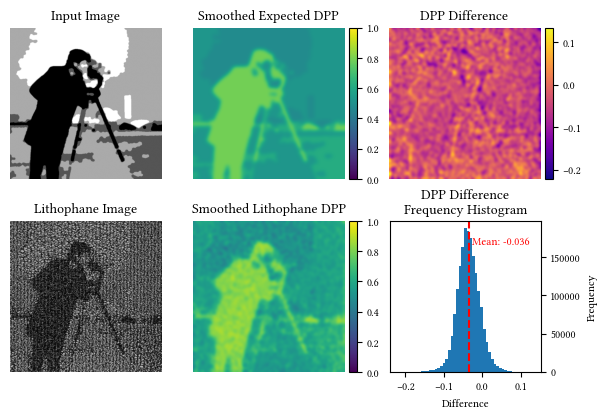

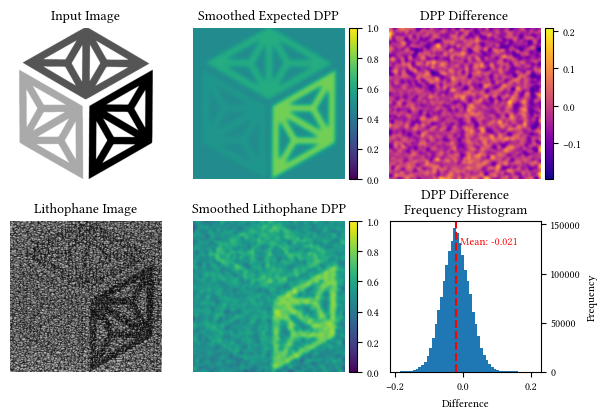

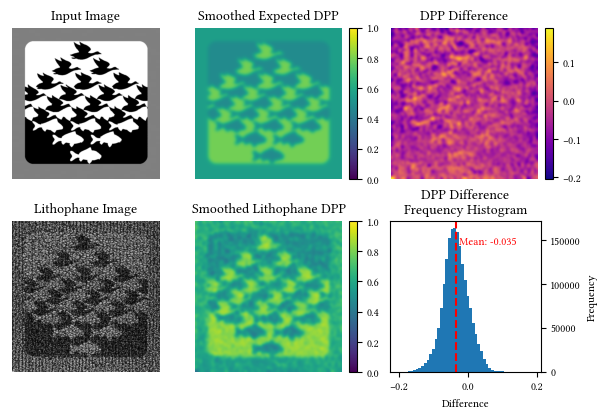

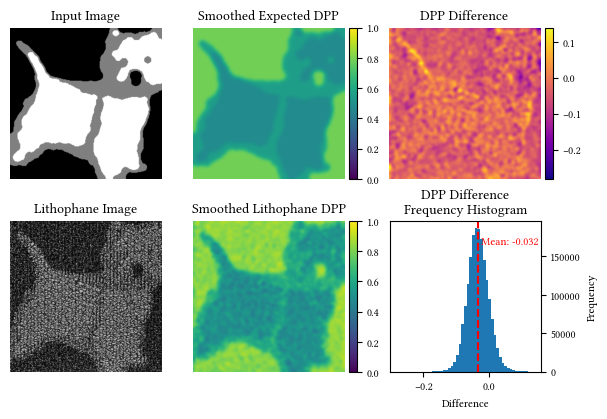

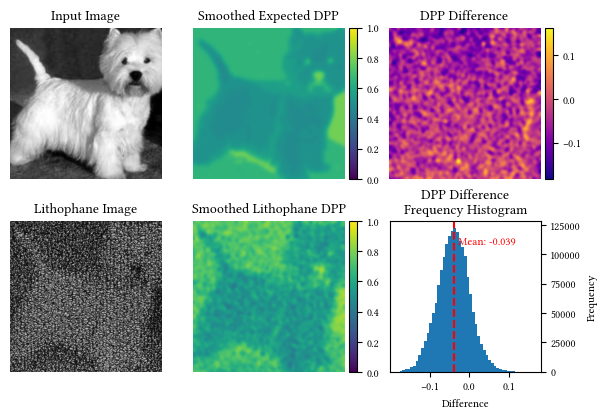

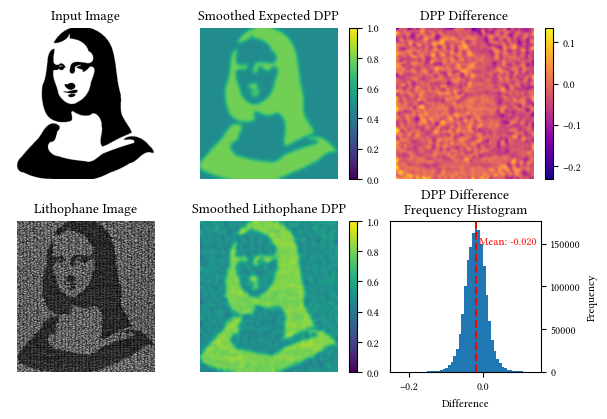

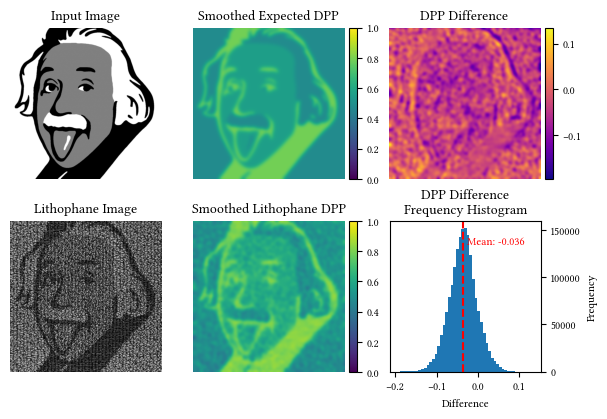

In [230]:
image_pairs = {
    'cameraman': {
        'litho_img': "./images/cameraman_Q4.JPG",
        'input_img': "../images/cameraman_Q4.png",
        'qlvl': 4,
    },
    'SCF': {
        'litho_img': "./images/SCF_Q4.JPG",
        'input_img': "../images/SCF_white_BGND_raw.png",
        'qlvl': 4
    },
    'SAW': {
        'litho_img': "./images/sky_and_water_I_Q3.JPG",
        'input_img': "../images/Sky_and_Water_I_Q3.png",
        'qlvl': 3
    },
    'terrier_Q3': {
        'litho_img': "./images/terrier_Q3.JPG",
        'input_img': "../images/terrier_Q3.png",
        'qlvl': 3
    },
    'terrier_raw': {
        'litho_img': "./images/terrier_raw.JPG",
        'input_img': "../images/terrier_raw.jpg",
        'qlvl': 5
    },
    'mona_lisa': {
        'litho_img': "./images/mona_lisa_Q2.JPG",
        'input_img': "../images/mona_lisa_Q2.png",
        'qlvl': 2
    },
    'einstein_1p5-4p5': {
        'litho_img': "./images/einstein_Q3_1p5-4p5.JPG",
        'input_img': "../images/einstein_Q3.png",
        'qlvl': 3
    },
}

for key, value in image_pairs.items():
    # if 'camera' in key:
    #     break
    litho_img = value['litho_img']
    input_img = value['input_img']
    qlvl = value['qlvl']
    print(f"Processing {key}...")
    fig = compare_dark_pct(litho_img, input_img, qlvl,
                           litho_size_mm=200., homogenizing_size_mm=5.)

    # break
    # fig.savefig(f"./output_figs/{key}_dark_pct_comparison.svg")
    fig.savefig(f"./output_figs/{key}_dark_pct_comparison.svg",
                format='svg',
                bbox_inches='tight',
                dpi=300,
                transparent=False
                )

(668, 668) (668, 668)
68 -36
Calibration Backlight Mean: 167.36
Swatch Backlight Mean: 176.16
Difference Mean: -8.79


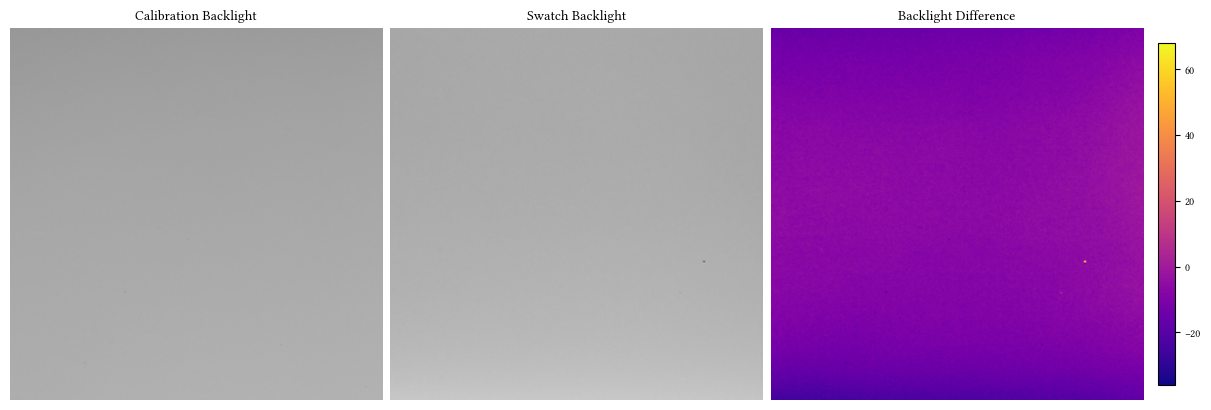

In [231]:
# compare backlights for intensity differences

from scipy.ndimage import median_filter
from cycler import V
from numpy import diff


cal_backlight = Image.open("./images/backlighting/250701_001_backlight.JPG")
cal_backlight = cal_backlight.convert('L')  # Convert to grayscale
cal_backlight = np.array(cal_backlight, dtype=np.uint8)
swatch_backlight = Image.open(
    "./images/backlighting/swatch_array_backlight.JPG")
swatch_backlight = swatch_backlight.convert('L')  # Convert to grayscale
swatch_backlight = np.array(swatch_backlight, dtype=np.uint8)
if swatch_backlight.shape != cal_backlight.shape:
    cal_backlight = cv2.resize(
        cal_backlight, (swatch_backlight.shape[1], swatch_backlight.shape[0]), interpolation=cv2.INTER_AREA)

# cal_backlight = median_filter(cal_backlight, size=10)
# swatch_backlight = median_filter(swatch_backlight, size=10)

print(cal_backlight.shape, swatch_backlight.shape)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axs[0].imshow(cal_backlight, cmap='gray', vmin=0, vmax=255)
axs[0].set_title("Calibration Backlight")
axs[0].axis('off')
axs[1].imshow(swatch_backlight, cmap='gray', vmin=0, vmax=255)
axs[1].set_title("Swatch Backlight")
axs[1].axis('off')
diff_backlight = cal_backlight.astype(
    np.int16) - swatch_backlight.astype(np.int16)

p = axs[2].imshow(diff_backlight, cmap='plasma')
axs[2].set_title("Backlight Difference")
axs[2].axis('off')
plt.colorbar(p, ax=axs[2], fraction=0.046, pad=0.04)
print(np.max(diff_backlight), np.min(diff_backlight))

cal_mean = np.mean(cal_backlight)
swatch_mean = np.mean(swatch_backlight)
print(f"Calibration Backlight Mean: {cal_mean:.2f}")
print(f"Swatch Backlight Mean: {swatch_mean:.2f}")
print(f"Difference Mean: {np.mean(diff_backlight):.2f}")